# Programação e Análise Computacional do Teorema de Bayes

A estrutura segue a ordem solicitada no exercício:

1. Descrição e mapeamento de variáveis;
2. Implementação algorítmica parametrizada;
3. Análise gráfica da atualização bayesiana.


In [1]:
# Bibliotecas utilizadas no notebook
import pandas as pd
import matplotlib.pyplot as plt

# Configuração visual básica dos gráficos
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


## Exemplo 1 — Diagnóstico de COVID-19

O problema analisa a chance real de uma pessoa estar infectada por COVID-19 após receber um resultado positivo em um teste rápido de antígeno.

Mapeamento bayesiano:

- Evento principal **A**: pessoa está com COVID-19.
- Evidência **B**: teste deu positivo.
- Probabilidade a priori: **P(COVID) = 0,02**, isto é, prevalência de 2% na população testada.
- Verossimilhança: **P(Positivo | COVID) = 0,85**, isto é, sensibilidade de 85%.
- Falso positivo: **P(Positivo | Não COVID) = 1 - especificidade = 1 - 0,98 = 0,02**.
- Probabilidade a posteriori desejada: **P(COVID | Positivo)**.

In [10]:
# Passo 1: definir as informações do problema
prevalencia_covid = 0.02
sensibilidade_teste = 0.85
especificidade_teste = 0.98

# Passo 2: calcular a probabilidade de falso positivo
# Como o teste pode errar mesmo quando a pessoa não está doente,
# usamos o valor complementar da especificidade.
falso_positivo_covid = 1 - especificidade_teste
prior_nao_covid = 1 - prevalencia_covid

# Passo 3: calcular a probabilidade total de obter um resultado positivo
# P(Positivo) = P(Positivo | COVID) * P(COVID) + P(Positivo | Não COVID) * P(Não COVID)
prob_positivo = (
    sensibilidade_teste * prevalencia_covid
    + falso_positivo_covid * prior_nao_covid
)

# Passo 4: aplicar o Teorema de Bayes para atualizar a probabilidade
# P(COVID | Positivo) = P(Positivo | COVID) * P(COVID) / P(Positivo)
posterior_covid = (sensibilidade_teste * prevalencia_covid) / prob_positivo
posterior_nao_covid = 1 - posterior_covid

# Passo 5: mostrar os resultados de forma interpretável
print("Exemplo 1 - Diagnóstico de COVID-19")
print(f"P(Positivo) = {prob_positivo:.4f} = {prob_positivo:.2%}")
print(f"P(COVID | Positivo) = {posterior_covid:.4f} = {posterior_covid:.2%}")
print(f"P(Não COVID | Positivo) = {posterior_nao_covid:.4f} = {posterior_nao_covid:.2%}")


Exemplo 1 - Diagnóstico de COVID-19
P(Positivo) = 0.0366 = 3.66%
P(COVID | Positivo) = 0.4645 = 46.45%
P(Não COVID | Positivo) = 0.5355 = 53.55%


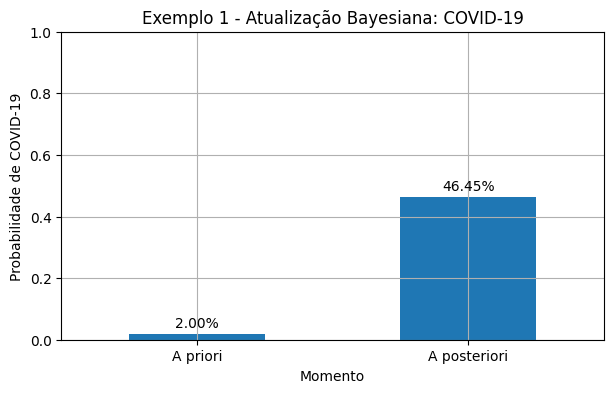

In [11]:
# Gráfico da atualização bayesiana para o exemplo do COVID-19
# Aqui comparamos a probabilidade inicial com a probabilidade atualizada
# após observar a evidência do teste positivo.

dados = pd.DataFrame({
    "Momento": ["A priori", "A posteriori"],
    "Probabilidade": [prevalencia_covid, posterior_covid]
})

ax = dados.plot(kind="bar", x="Momento", y="Probabilidade", legend=False)
ax.set_title("Exemplo 1 - Atualização Bayesiana: COVID-19")
ax.set_ylabel("Probabilidade de COVID-19")
ax.set_ylim(0, 1)

for i, valor in enumerate(dados["Probabilidade"]):
    ax.text(i, valor + 0.02, f"{valor:.2%}", ha="center")

plt.xticks(rotation=0)
plt.show()


## Exemplo 2 — Câncer de mama

O problema calcula a probabilidade de uma mulher realmente ter câncer de mama após obter resultado positivo em uma mamografia.

Mapeamento bayesiano:

- Evento principal **A**: mulher possui câncer de mama.
- Evidência **B**: mamografia deu positivo.
- Probabilidade a priori: **P(Câncer) = 0,01**, ou seja, prevalência de 1%.
- Verossimilhança: **P(Positivo | Câncer) = 0,80**.
- Falso positivo: **P(Positivo | Sem câncer) = 0,096**.
- Probabilidade a posteriori desejada: **P(Câncer | Positivo)**.

In [4]:
# Exemplo 2 - Câncer de mama
# Passo 1: definir os dados do problema
prevalencia_cancer = 0.01
sensibilidade_mamografia = 0.80
falso_positivo_mamografia = 0.096

# Passo 2: calcular a probabilidade de um resultado positivo na mamografia
# A evidência positiva pode acontecer tanto em quem tem câncer quanto em quem não tem.
prior_sem_cancer = 1 - prevalencia_cancer

prob_positivo_mamografia = (
    sensibilidade_mamografia * prevalencia_cancer
    + falso_positivo_mamografia * prior_sem_cancer
)

# Passo 3: aplicar o Teorema de Bayes para atualizar a probabilidade
posterior_cancer = (sensibilidade_mamografia * prevalencia_cancer) / prob_positivo_mamografia
posterior_sem_cancer = 1 - posterior_cancer

# Passo 4: exibir a interpretação do resultado
print("Exemplo 2 - Câncer de mama")
print(f"P(Positivo) = {prob_positivo_mamografia:.5f} = {prob_positivo_mamografia:.2%}")
print(f"P(Câncer | Positivo) = {posterior_cancer:.5f} = {posterior_cancer:.2%}")
print(f"P(Sem câncer | Positivo) = {posterior_sem_cancer:.5f} = {posterior_sem_cancer:.2%}")


Exemplo 2 - Câncer de mama
P(Positivo) = 0.10304 = 10.30%
P(Câncer | Positivo) = 0.07764 = 7.76%
P(Sem câncer | Positivo) = 0.92236 = 92.24%


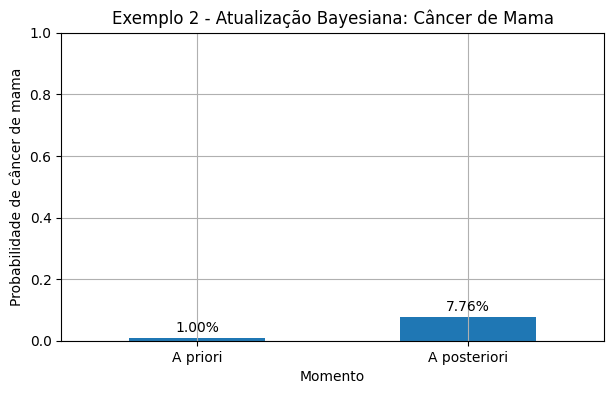

In [5]:
# Gráfico da atualização bayesiana para o exemplo do câncer de mama
# O objetivo é mostrar que, mesmo com exame positivo, a probabilidade posterior
# ainda é influenciada pela baixa prevalência inicial do problema.

dados = pd.DataFrame({
    "Momento": ["A priori", "A posteriori"],
    "Probabilidade": [prevalencia_cancer, posterior_cancer]
})

ax = dados.plot(kind="bar", x="Momento", y="Probabilidade", legend=False)
ax.set_title("Exemplo 2 - Atualização Bayesiana: Câncer de Mama")
ax.set_ylabel("Probabilidade de câncer de mama")
ax.set_ylim(0, 1)

for i, valor in enumerate(dados["Probabilidade"]):
    ax.text(i, valor + 0.02, f"{valor:.2%}", ha="center")

plt.xticks(rotation=0)
plt.show()


## Exemplo 3 — Teste de gravidez

O problema calcula a chance de Lica estar realmente grávida dado que o teste de farmácia apresentou resultado positivo.

Mapeamento bayesiano:

- Evento principal **A**: Lica está grávida.
- Evidência **B**: teste de gravidez deu positivo.
- Probabilidade a priori: **P(Grávida) = 0,05**, isto é, chance inicial de 5%.
- Verossimilhança: **P(Positivo | Grávida) = 0,99**, isto é, sensibilidade de 99%.
- Falso positivo: **P(Positivo | Não grávida) = 1 - especificidade = 1 - 0,99 = 0,01**.
- Probabilidade a posteriori desejada: **P(Grávida | Positivo)**.

In [6]:
# Exemplo 3 - Teste de gravidez
# Passo 1: definir os valores do problema
prior_gravidez = 0.05
sensibilidade_gravidez = 0.99
especificidade_gravidez = 0.99

# Passo 2: calcular a chance de falso positivo do teste
# Como em qualquer teste, há uma possibilidade de erro mesmo quando a pessoa não está grávida.
falso_positivo_gravidez = 1 - especificidade_gravidez
prior_nao_gravidez = 1 - prior_gravidez

# Passo 3: calcular a probabilidade total de obter um resultado positivo
prob_positivo_gravidez = (
    sensibilidade_gravidez * prior_gravidez
    + falso_positivo_gravidez * prior_nao_gravidez
)

# Passo 4: aplicar o Teorema de Bayes para atualizar a probabilidade
posterior_gravidez = (sensibilidade_gravidez * prior_gravidez) / prob_positivo_gravidez
posterior_nao_gravidez = 1 - posterior_gravidez

# Passo 5: mostrar os resultados para interpretação
print("Exemplo 3 - Teste de gravidez")
print(f"P(Positivo) = {prob_positivo_gravidez:.4f} = {prob_positivo_gravidez:.2%}")
print(f"P(Grávida | Positivo) = {posterior_gravidez:.4f} = {posterior_gravidez:.2%}")
print(f"P(Não grávida | Positivo) = {posterior_nao_gravidez:.4f} = {posterior_nao_gravidez:.2%}")


Exemplo 3 - Teste de gravidez
P(Positivo) = 0.0590 = 5.90%
P(Grávida | Positivo) = 0.8390 = 83.90%
P(Não grávida | Positivo) = 0.1610 = 16.10%


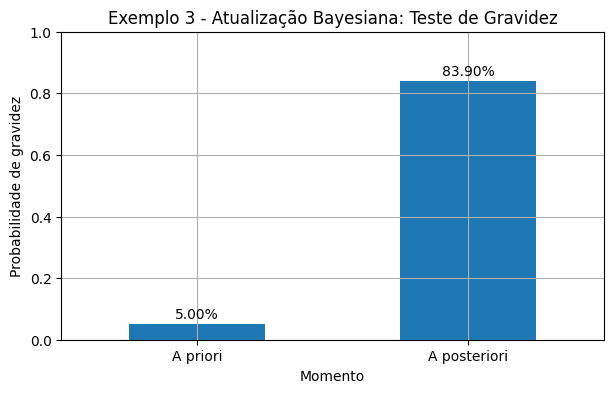

In [7]:
# Gráfico da atualização bayesiana para o exemplo do teste de gravidez
# Aqui a ideia é comparar o valor inicial de gravidez com o valor revisado
# após observar o resultado positivo do teste.

dados = pd.DataFrame({
    "Momento": ["A priori", "A posteriori"],
    "Probabilidade": [prior_gravidez, posterior_gravidez]
})

ax = dados.plot(kind="bar", x="Momento", y="Probabilidade", legend=False)
ax.set_title("Exemplo 3 - Atualização Bayesiana: Teste de Gravidez")
ax.set_ylabel("Probabilidade de gravidez")
ax.set_ylim(0, 1)

for i, valor in enumerate(dados["Probabilidade"]):
    ax.text(i, valor + 0.02, f"{valor:.2%}", ha="center")

plt.xticks(rotation=0)
plt.show()


## Exemplo 5 — Tomada de decisão sobre empréstimos

O problema utiliza o algoritmo Naive Bayes para classificar o risco de Maria como **Bom** ou **Ruim**, a partir de quatro evidências: histórico com o banco, estado civil, tempo de emprego e posse de casa.

Mapeamento bayesiano:

- Classe **Bom**: representa empréstimo aprovado.
- Classe **Ruim**: representa empréstimo negado.
- Evidência **E**: perfil de Maria = Sem Dívidas, Solteira, ≤ 2 anos de emprego, Alugada.
- Probabilidade a priori: **P(Bom) = 9/14** e **P(Ruim) = 5/14**, obtidas da tabela de treinamento.
- Verossimilhança: produto das probabilidades condicionais de cada característica dado cada classe, assumindo independência entre as variáveis.
- Probabilidade a posteriori desejada: **P(Bom | E)** e **P(Ruim | E)**.

In [8]:
# Exemplo 5 - Tomada de decisão sobre empréstimos
# Tabela de treinamento extraída do exemplo do TCC
# Cada linha representa um cliente anterior.

dados_credito = pd.DataFrame([
    ["H Solteiro",   "Existe Dívidas",  "≤ 2 anos", "Própria", "Ruim"],
    ["H Solteiro",   "Existe Dívidas",  "≤ 2 anos", "Alugada", "Ruim"],
    ["M Divorciada", "Existe Dívidas",  "≤ 2 anos", "Própria", "Bom"],
    ["M Solteira",   "Sem Dívidas",     "≤ 2 anos", "Própria", "Bom"],
    ["M Solteira",   "Crítico Dívidas", "> 2 anos", "Própria", "Bom"],
    ["M Solteira",   "Crítico Dívidas", "> 2 anos", "Alugada", "Ruim"],
    ["M Divorciada", "Crítico Dívidas", "> 2 anos", "Alugada", "Bom"],
    ["H Solteiro",   "Sem Dívidas",     "≤ 2 anos", "Própria", "Ruim"],
    ["H Solteiro",   "Crítico Dívidas", "> 2 anos", "Própria", "Bom"],
    ["M Solteira",   "Sem Dívidas",     "> 2 anos", "Própria", "Bom"],
    ["H Solteiro",   "Sem Dívidas",     "> 2 anos", "Alugada", "Bom"],
    ["M Divorciada", "Sem Dívidas",     "≤ 2 anos", "Alugada", "Bom"],
    ["M Divorciada", "Existe Dívidas",  "> 2 anos", "Própria", "Bom"],
    ["M Solteira",   "Sem Dívidas",     "≤ 2 anos", "Alugada", "Ruim"],
], columns=["Situacao", "Historico", "Emprego", "Casa", "Risco"])

# Perfil de Maria - altere os valores para testar outras situações
perfil_maria = {
    "Situacao": "M Solteira",
    "Historico": "Sem Dívidas",
    "Emprego": "≤ 2 anos",
    "Casa": "Alugada"
}

classe_alvo = "Risco"
classes = dados_credito[classe_alvo].unique()

# Cálculo Naive Bayes sem suavização, seguindo o exemplo analítico do TCC
resultados = {}

for classe in classes:
    dados_classe = dados_credito[dados_credito[classe_alvo] == classe]
    prior = len(dados_classe) / len(dados_credito)

    verossimilhanca = 1
    condicionais = {}

    for variavel, valor in perfil_maria.items():
        prob_condicional = (dados_classe[variavel] == valor).sum() / len(dados_classe)
        condicionais[f"P({valor} | {classe})"] = prob_condicional
        verossimilhanca *= prob_condicional

    prob_nao_normalizada = prior * verossimilhanca

    resultados[classe] = {
        "prior": prior,
        "verossimilhanca": verossimilhanca,
        "prob_nao_normalizada": prob_nao_normalizada,
        "condicionais": condicionais
    }

# Normalização das probabilidades para obter os posteriores
soma = sum(info["prob_nao_normalizada"] for info in resultados.values())
for classe in classes:
    resultados[classe]["posterior"] = resultados[classe]["prob_nao_normalizada"] / soma

print("Exemplo 5 - Naive Bayes para análise de crédito")
print("Perfil avaliado:", perfil_maria)
print()

for classe, info in resultados.items():
    print(f"Classe: {classe}")
    print(f"  Prior P({classe}) = {info['prior']:.4f} = {info['prior']:.2%}")
    print(f"  Verossimilhança P(E | {classe}) = {info['verossimilhanca']:.4f}")
    print(f"  Posterior P({classe} | E) = {info['posterior']:.4f} = {info['posterior']:.2%}")
    print("  Probabilidades condicionais:")
    for nome, valor in info["condicionais"].items():
        print(f"    {nome} = {valor:.4f}")
    print()

decisao = max(resultados, key=lambda classe: resultados[classe]["posterior"])
print(f"Decisão do modelo: {decisao}")

if decisao == "Bom":
    print("Interpretação: o empréstimo seria aprovado.")
else:
    print("Interpretação: o empréstimo seria negado.")

Exemplo 5 - Naive Bayes para análise de crédito
Perfil avaliado: {'Situacao': 'M Solteira', 'Historico': 'Sem Dívidas', 'Emprego': '≤ 2 anos', 'Casa': 'Alugada'}

Classe: Ruim
  Prior P(Ruim) = 0.3571 = 35.71%
  Verossimilhança P(E | Ruim) = 0.0768
  Posterior P(Ruim | E) = 0.7216 = 72.16%
  Probabilidades condicionais:
    P(M Solteira | Ruim) = 0.4000
    P(Sem Dívidas | Ruim) = 0.4000
    P(≤ 2 anos | Ruim) = 0.8000
    P(Alugada | Ruim) = 0.6000

Classe: Bom
  Prior P(Bom) = 0.6429 = 64.29%
  Verossimilhança P(E | Bom) = 0.0165
  Posterior P(Bom | E) = 0.2784 = 27.84%
  Probabilidades condicionais:
    P(M Solteira | Bom) = 0.3333
    P(Sem Dívidas | Bom) = 0.4444
    P(≤ 2 anos | Bom) = 0.3333
    P(Alugada | Bom) = 0.3333

Decisão do modelo: Ruim
Interpretação: o empréstimo seria negado.


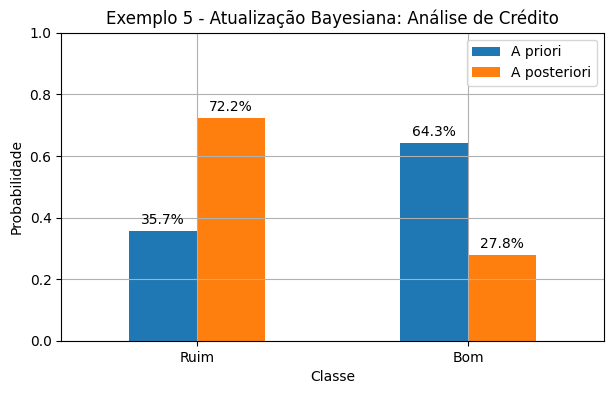

In [9]:
# Construção do gráfico comparando prior e posterior das duas classes
comparativo_credito = pd.DataFrame({
    "Classe": list(resultados.keys()),
    "A priori": [resultados[c]["prior"] for c in resultados],
    "A posteriori": [resultados[c]["posterior"] for c in resultados]
})

ax = comparativo_credito.set_index("Classe").plot(kind="bar")
ax.set_title("Exemplo 5 - Atualização Bayesiana: Análise de Crédito")
ax.set_ylabel("Probabilidade")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{v.get_height():.1%}" for v in container], padding=3)

plt.show()

## Conclusão geral

Os quatro exemplos mostram que o Teorema de Bayes permite atualizar uma crença inicial a partir de novas evidências. Nos exemplos médicos, a probabilidade a posteriori é fortemente influenciada pela prevalência inicial do evento. No exemplo de crédito, o Naive Bayes usa a combinação das evidências do perfil do cliente para comparar as classes **Bom** e **Ruim**.

Como o notebook foi parametrizado, é possível alterar as prevalências, sensibilidades, especificidades ou os dados de entrada para observar como os resultados mudam.